In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('default')

## `Problem 1 to 5`:

Dataset link: https://tinyurl.com/2fe6vz4u

**Add a label to every axis and add a proper title for the charts. Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.


### **`Problem-1:`** Draw a line plot of which, the x-axis is the "Year" and the y-axis is sum of "PM2.5" of two countries Iran and China.

In [2]:
# code here
df = pd.read_csv('datasets/most-polluted cities.csv')
df.head()

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018
3,3,4,India,Varanasi,2016,146,>75%,260,NaN,2018
4,4,5,India,Patna,2016,144,>75%,266,NaN,2018


In [16]:
iran_series = df.query('Country == "Iran"').groupby('Year')['PM2.5'].sum()
china_series = df.query('Country == "China"').groupby('Year')['PM2.5'].sum()

In [17]:
iran_series

Year
2012      37
2013      66
2014      31
2016    1453
Name: PM2.5, dtype: int64

In [18]:
china_series

Year
2014     2725
2015      425
2016    11106
Name: PM2.5, dtype: int64

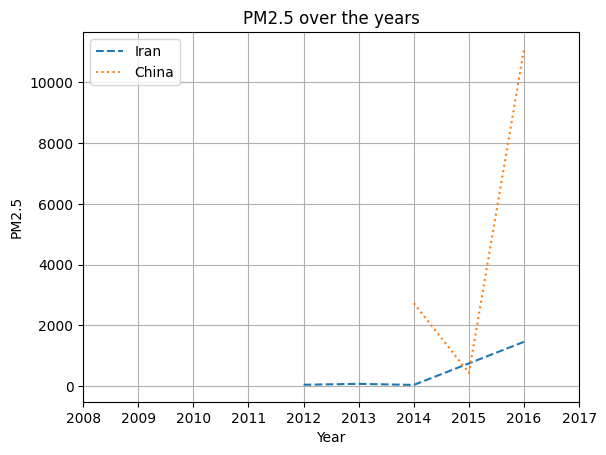

In [25]:
plt.plot(iran_series.index, iran_series.values, label="Iran", linestyle='dashed')
plt.plot(china_series.index, china_series.values, label="China", linestyle='dotted')
plt.xlabel('Year')
plt.ylabel('PM2.5')
plt.title('PM2.5 over the years')
plt.xticks(df['Year'].value_counts().index)
plt.grid()
plt.legend()
plt.show()

In [26]:
df['Year'].value_counts().index

Index([2016, 2014, 2015, 2012, 2013, 2010, 2011, 2008, 2017, 2009], dtype='int64', name='Year')

### **`Problem-2:`** Draw a histogram of the  column "PM10" of which the y-axis represents the probability (see the documentation how to draw the probability).

(array([269., 169.,  37.,  10.,   8.,   5.,   0.,   0.,   1.,   1.]),
 array([ 29. ,  80.1, 131.2, 182.3, 233.4, 284.5, 335.6, 386.7, 437.8,
        488.9, 540. ]),
 <BarContainer object of 10 artists>)

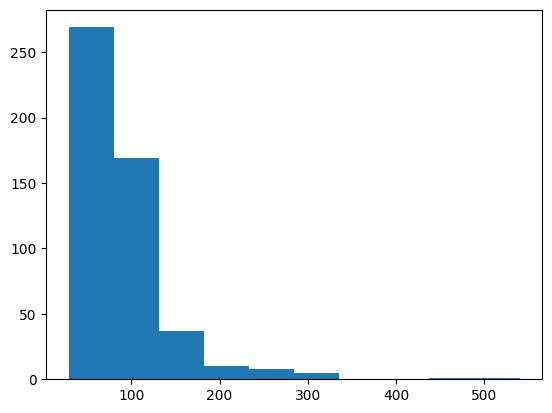

In [26]:
plt.hist(df['PM10'])

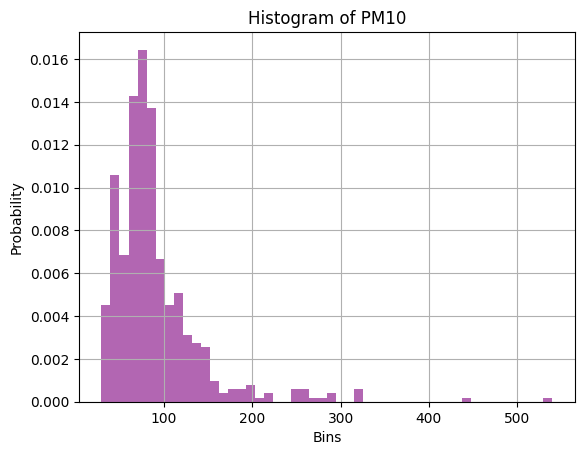

In [33]:
plt.hist(df['PM10'], density=True, bins=50, facecolor='purple', alpha=0.6)
plt.xlabel('Bins')
plt.ylabel('Probability')
plt.title('Histogram of PM10')
plt.grid()
plt.show()

In [ ]:
# density=True normalizes the histogram so it shows a probability density instead of raw counts.
# The total area of all bars becomes 1, not the total number of observations.
# Bar heights are scaled by count ÷ (total data × bin width).
# This lets you interpret the histogram like a probability distribution and compare across datasets.

### **`Problem-3:`** Draw a scatter plot where x-axis represents "PM2.5" and y-axis represents "PM10" for two countries Poland and Chile.

In [34]:
chile_df = df.query("Country ==  'Chile'")
poland_df = df.query("Country ==  'Poland'")

In [36]:
chile_df.head(3)

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
75,75,76,Chile,Comuna De Coyhaique,2016,67,NaN,85,NaN,2018
89,89,90,Chile,Coyhaique,2014,64,NaN,75,NaN,2016
190,190,191,Chile,Padre Las Casas,2016,49,NaN,64,NaN,2018


In [37]:
poland_df.head(3)

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
370,370,371,Poland,Godów,2016,33,>75%,43,>75%,2018
371,371,372,Poland,Pleszew,2016,33,>75%,38,>75%,2018
392,392,393,Poland,Gliwice,2016,32,>75%,46,>75%,2018


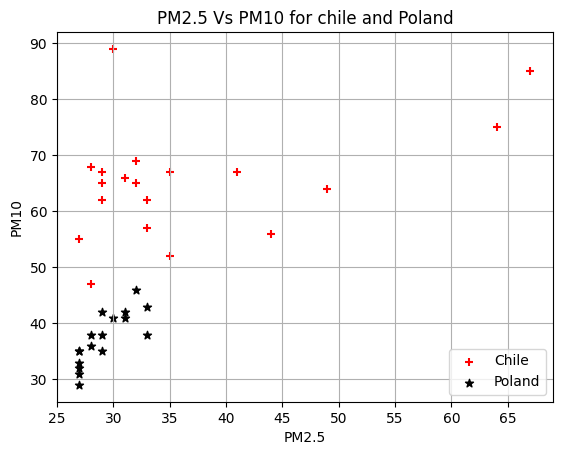

In [43]:
plt.scatter(chile_df['PM2.5'], chile_df['PM10'], marker='+', color='red', label='Chile')
plt.scatter(poland_df['PM2.5'], poland_df['PM10'], marker='*', color='black', label='Poland')
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.title('PM2.5 Vs PM10 for chile and Poland')
plt.legend()
plt.grid()
plt.show()

### **`Problem-4:`** Draw a pie chart of top 5 most frequent countries.

In [48]:
top_con = df['Country'].value_counts().head()

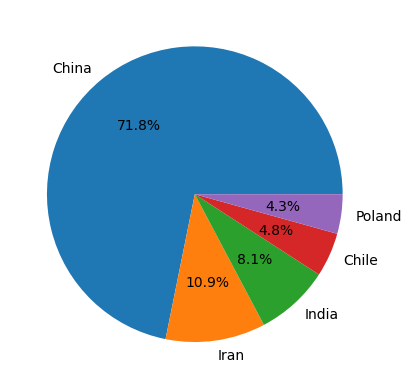

In [51]:
plt.pie(top_con, labels=top_con.index, autopct="%0.1f%%")
plt.show()

### **`Problem-5:`** Draw a bar chart which represents the counts of top 5 most frequent countries.



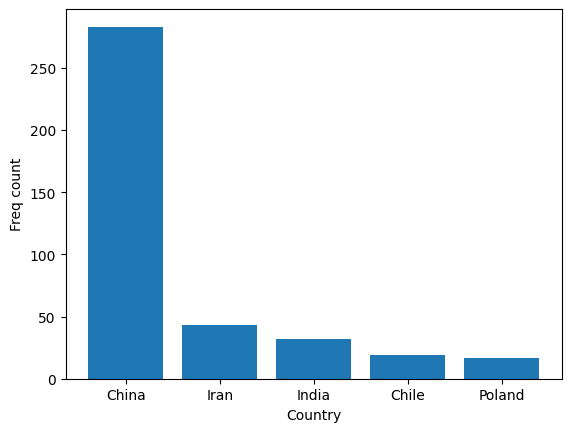

In [53]:
plt.bar(top_con.index, top_con)
plt.xlabel('Country')
plt.ylabel('Freq count')
plt.show()

## `Problem 6-10`

Data Set - https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv

This is a Sales data of any company in a Year.


### `Problem-6`
Show a line plot of Total Profit for each month with below styling.
* Dotted Line
* Line Color Blue
* Show Legend at top left
* Circle Marker

In [54]:
df = pd.read_csv('datasets/company_sales_data.csv')
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


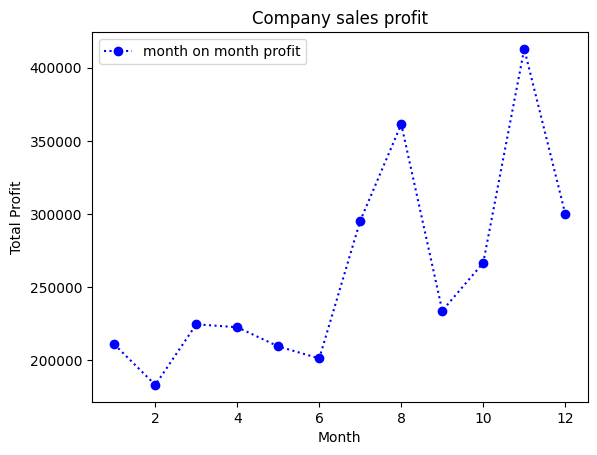

In [59]:
plt.plot(df['month_number'], df['total_profit'], label='month on month profit', color='blue', marker='o', linestyle='dotted')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.title('Company sales profit')
plt.legend(loc='upper left')
plt.show()

### `Problem-7` 
Show sales of each product in march month as pie chart. 
* Show Percentage value 
* Give Title "Sales in March"
* Explode ToothPaste with shadow

In [76]:
labels = df[df['month_number'] == 3].iloc[:,1:7].stack().index.get_level_values(1)
values = df[df['month_number'] == 3].iloc[:,1:7].stack().values

In [77]:
labels

Index(['facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo',
       'moisturizer'],
      dtype='object')

In [78]:
values

array([2140, 1340, 4550, 9550, 3550, 1340])

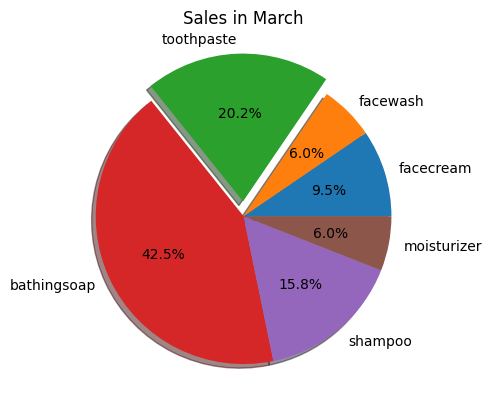

In [87]:
plt.pie(values,labels=labels ,autopct='%0.1f%%', explode=[0,0,0.1,0,0,0], shadow=True)
plt.title('Sales in March')
plt.show()

### `Problem-8` Multiline Plot of all products sales.
* Give different styes for each products
* Add legend at top right

In [90]:
monthList  = df['month_number'].tolist()
monthList 

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

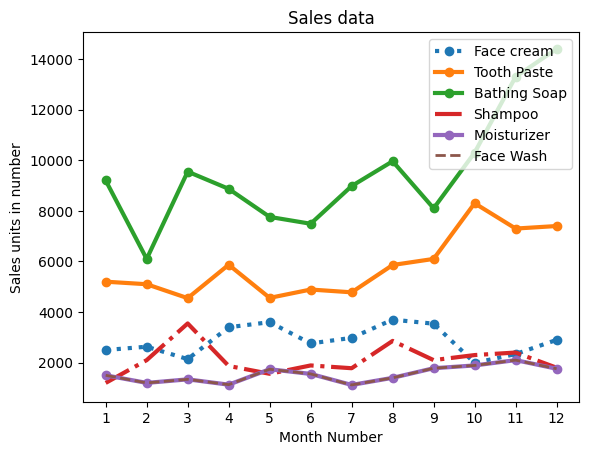

In [92]:
monthList  = df['month_number'].tolist()

plt.plot(monthList, df['facecream'],   label = 'Face cream', linestyle='dotted', marker='o', linewidth=3)
plt.plot(monthList, df['toothpaste'], label = 'Tooth Paste', marker='o', linewidth=3)
plt.plot(monthList, df['bathingsoap'], label = 'Bathing Soap', marker='o', linewidth=3)
plt.plot(monthList, df['shampoo'], label = 'Shampoo', linestyle='dashdot', linewidth=3)
plt.plot(monthList, df['moisturizer'], label = 'Moisturizer', marker='o', linewidth=3)
plt.plot(monthList, df['facewash'],   label = 'Face Wash',  linestyle='dashed', linewidth=2)


plt.xlabel('Month Number')
plt.ylabel('Sales units in number')
plt.legend(loc='upper right')
plt.xticks(monthList)
plt.title('Sales data')
plt.show()

### `Problem-9` Show Quarter wise Sales data for all products as multi Bar chart.


In [93]:
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


In [100]:
df['date'] = pd.to_datetime(['2020-{}-01'.format(month) for month in df['month_number']])
df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit,date
0,1,2500,1500,5200,9200,1200,1500,21100,211000,2020-01-01
1,2,2630,1200,5100,6100,2100,1200,18330,183300,2020-02-01
2,3,2140,1340,4550,9550,3550,1340,22470,224700,2020-03-01
3,4,3400,1130,5870,8870,1870,1130,22270,222700,2020-04-01
4,5,3600,1740,4560,7760,1560,1740,20960,209600,2020-05-01
5,6,2760,1555,4890,7490,1890,1555,20140,201400,2020-06-01
6,7,2980,1120,4780,8980,1780,1120,29550,295500,2020-07-01
7,8,3700,1400,5860,9960,2860,1400,36140,361400,2020-08-01
8,9,3540,1780,6100,8100,2100,1780,23400,234000,2020-09-01
9,10,1990,1890,8300,10300,2300,1890,26670,266700,2020-10-01


In [105]:
final_df = df.groupby(df['date'].dt.quarter).sum(numeric_only=True)
final_df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
date,,,,,,,,,
1,6,7270,4040,14850,24850,6850,4040,61900,619000
2,15,9760,4425,15320,24120,5320,4425,63370,633700
3,24,10220,4300,16740,27040,6740,4300,89090,890900
4,33,7230,5750,23000,38000,6500,5750,97970,979700


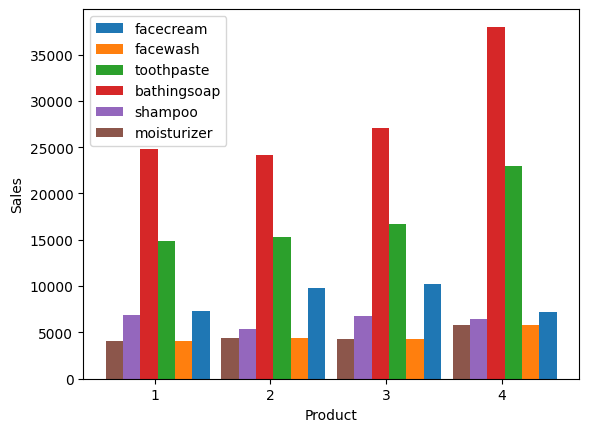

In [106]:
i = -1
for col in final_df.columns[1:7]:
  plt.bar(final_df.index + i,final_df[col],width=0.15,label=col)
  i = i - 0.15

plt.xticks(final_df.index-1.4,final_df.index)
plt.xlabel('Product')
plt.ylabel('Sales')
plt.legend()
plt.show()

### `Problem-10` Plot Stacked Bar chart quarter wise for each product.

In [107]:
final_df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
date,,,,,,,,,
1,6,7270,4040,14850,24850,6850,4040,61900,619000
2,15,9760,4425,15320,24120,5320,4425,63370,633700
3,24,10220,4300,16740,27040,6740,4300,89090,890900
4,33,7230,5750,23000,38000,6500,5750,97970,979700


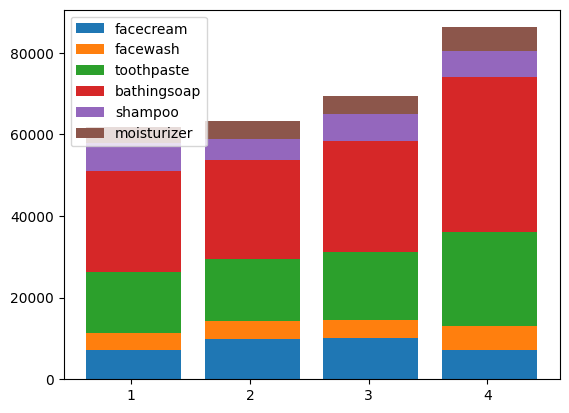

In [110]:
all_cols = []

for col in final_df.columns[1:7]:
  if len(all_cols) == 0:
    plt.bar(final_df.index,final_df[col],label=col)
  else:
    plt.bar(final_df.index,final_df[col],bottom=sum(all_cols),label=col)
  all_cols.append(final_df[col])

plt.xticks(final_df.index - 0.02, final_df.index)
plt.legend()
plt.show()